In [1]:
!git clone https://github.com/antisocialites/Deep-Learning.git

Cloning into 'Deep-Learning'...
remote: Enumerating objects: 154, done.
remote: Counting objects: 100% (154/154), done.
remote: Compressing objects: 100% (124/124), done.
remote: Total 154 (delta 24), reused 133 (delta 17), pack-reused 0 (from 0)
Receiving objects: 100% (154/154), 17.21 MiB | 8.79 MiB/s, done.
Resolving deltas: 100% (24/24), done.


In [2]:
!pwd

/content


In [3]:
%cd 'Deep-Learning/Assignment 2'
!ls
import sys
sys.path.append('.')  # C

/content/Deep-Learning/Assignment 2
'clusters_subchunks - ankita.ipynb'  'subchunks without gridsearch.ipynb'
 clusters_subchunks.ipynb	      utils
 preprocessing_clusters.ipynb


In [4]:
import os
import glob
import re
import h5py
import numpy as np
import pandas as pd
import random
from typing import Tuple, Literal, Optional, List
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from scipy.signal import decimate
import matplotlib.pyplot as plt
import itertools
# For CNN/RNN
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, InputLayer
)
from tensorflow.keras.optimizers import Adam

from utils.preprocessing_utils import *
from utils.visual_utils import *
import gc
gc.collect()


0

In [5]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


# Training

## Intra Files

In [6]:
## TRAINING DATA ##

# intra 1
participant_id_intra = 105923
rest_intra, motor_intra, story_math_intra, wm_intra = load_participant_arrays(participant_id_intra, base_dir=r"/content/drive/MyDrive/DL part 2/Final Project data/Intra/train")


print("Rest:", None if rest_intra is None else rest_intra.shape)
print("Motor:", None if motor_intra is None else motor_intra.shape)
print("Story/Math:", None if story_math_intra is None else story_math_intra.shape)
print("Working Memory:", None if wm_intra is None else wm_intra.shape)


Rest: (248, 284992)
Motor: (248, 284992)
Story/Math: (248, 284992)
Working Memory: (248, 284992)


## Contra Files

In [7]:
## TRAINING DATA ##
'''
# contra 1
participant_id_c1 = 113922

#contra 2
participant_id_c2 = 164636


rest_c1, motor_c1, story_math_c1, wm_c1 = load_participant_arrays(participant_id_c1, base_dir=r"/content/drive/MyDrive/DL part 2/Final Project data/Cross/train")
rest_c2, motor_c2, story_math_c2, wm_c2 = load_participant_arrays(participant_id_c2, base_dir=r"/content/drive/MyDrive/DL part 2/Final Project data/Cross/train")


print("Rest:", None if rest_c2 is None else rest_c2.shape)
print("Motor:", None if motor_c2 is None else motor_c2.shape)
print("Story/Math:", None if story_math_c2 is None else story_math_c2.shape)
print("Working Memory:", None if wm_c2 is None else wm_c2.shape)'''

'\n# contra 1\nparticipant_id_c1 = 113922\n\n#contra 2\nparticipant_id_c2 = 164636\n\n\nrest_c1, motor_c1, story_math_c1, wm_c1 = load_participant_arrays(participant_id_c1, base_dir=r"/content/drive/MyDrive/DL part 2/Final Project data/Cross/train")\nrest_c2, motor_c2, story_math_c2, wm_c2 = load_participant_arrays(participant_id_c2, base_dir=r"/content/drive/MyDrive/DL part 2/Final Project data/Cross/train")\n\n\nprint("Rest:", None if rest_c2 is None else rest_c2.shape)\nprint("Motor:", None if motor_c2 is None else motor_c2.shape)\nprint("Story/Math:", None if story_math_c2 is None else story_math_c2.shape)\nprint("Working Memory:", None if wm_c2 is None else wm_c2.shape)'

## Training Intra

In [8]:
datasets = [rest_intra, motor_intra, story_math_intra, wm_intra]
task_names = ["rest", "motor", "story_math", "wm"]

# preprocessing all datasets
preprocessed_datasets = [
    preprocess_meg_data(
        data,
        scaling="zscore",
        downsample_method="decimate",
        target_rate=64,
        orig_rate=2034
    )
    for data in datasets
]

# clustering using averaged cosine similarity
sensor_order, cluster_labels, avg_sim_matrix = cossim_cluster_multi_task(
    preprocessed_datasets,
    n_clusters=5
)

# reorder and store data per task
reordered_data_dict = {}
sensor_order_dict = {}
cluster_labels_dict = {}

for preproc_data, name in zip(preprocessed_datasets, task_names):
    reordered_data = preproc_data[sensor_order, :]
    reordered_data_dict[f"reordered_data_{name}"] = reordered_data
    sensor_order_dict[f"sensor_order_{name}"] = sensor_order
    cluster_labels_dict[f"cluster_labels_{name}"] = cluster_labels


In [9]:
# maybe not the most efficient way oops
rest_data = reordered_data_dict["reordered_data_rest"]
rest_sensor_order = sensor_order_dict["sensor_order_rest"]
rest_clusters = cluster_labels_dict["cluster_labels_rest"]

motor_data = reordered_data_dict["reordered_data_motor"]
motor_sensor_order = sensor_order_dict["sensor_order_motor"]
motor_clusters = cluster_labels_dict["cluster_labels_motor"]

story_math_data = reordered_data_dict["reordered_data_story_math"]
story_math_sensor_order = sensor_order_dict["sensor_order_story_math"]
story_math_clusters = cluster_labels_dict["cluster_labels_story_math"]

wm_data = reordered_data_dict["reordered_data_wm"]
wm_sensor_order = sensor_order_dict["sensor_order_wm"]
wm_clusters = cluster_labels_dict["cluster_labels_wm"]


### Data Visualization

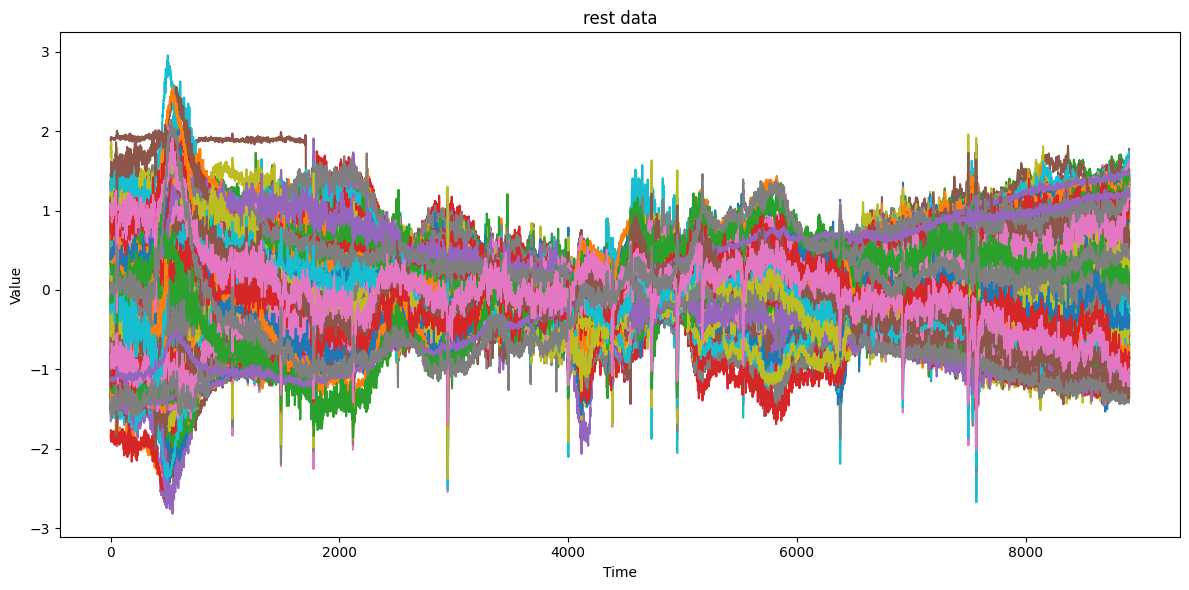

In [10]:
plt.figure(figsize=(12, 6))
for i in range(248):  # You can increase this to show more rows
    plt.plot(rest_data[i], label=f"Row {i}")

plt.xlabel("Time")
plt.ylabel("Value")
plt.title("rest data")
plt.tight_layout()
plt.show()

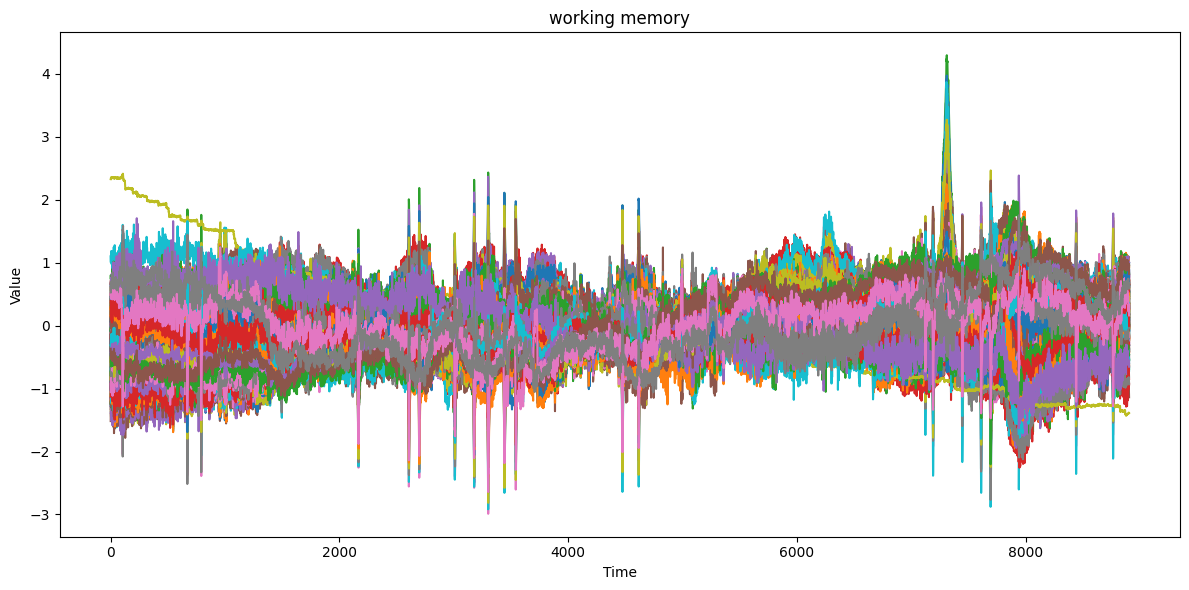

In [11]:
plt.figure(figsize=(12, 6))
for i in range(248):  # You can increase this to show more rows
    plt.plot(wm_data[i], label=f"Row {i}")

plt.xlabel("Time")
plt.ylabel("Value")
plt.title("working memory")
plt.tight_layout()
plt.show()

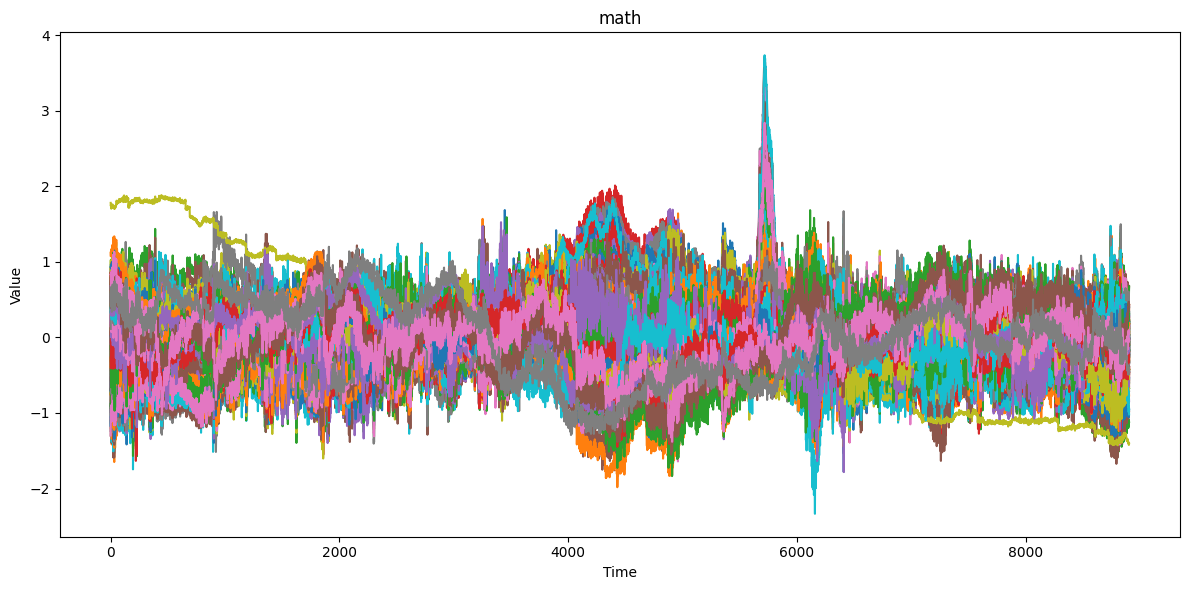

In [12]:
plt.figure(figsize=(12, 6))
for i in range(248):  # You can increase this to show more rows
    plt.plot(story_math_data[i], label=f"Row {i}")

plt.xlabel("Time")
plt.ylabel("Value")
plt.title("math")
plt.tight_layout()
plt.show()

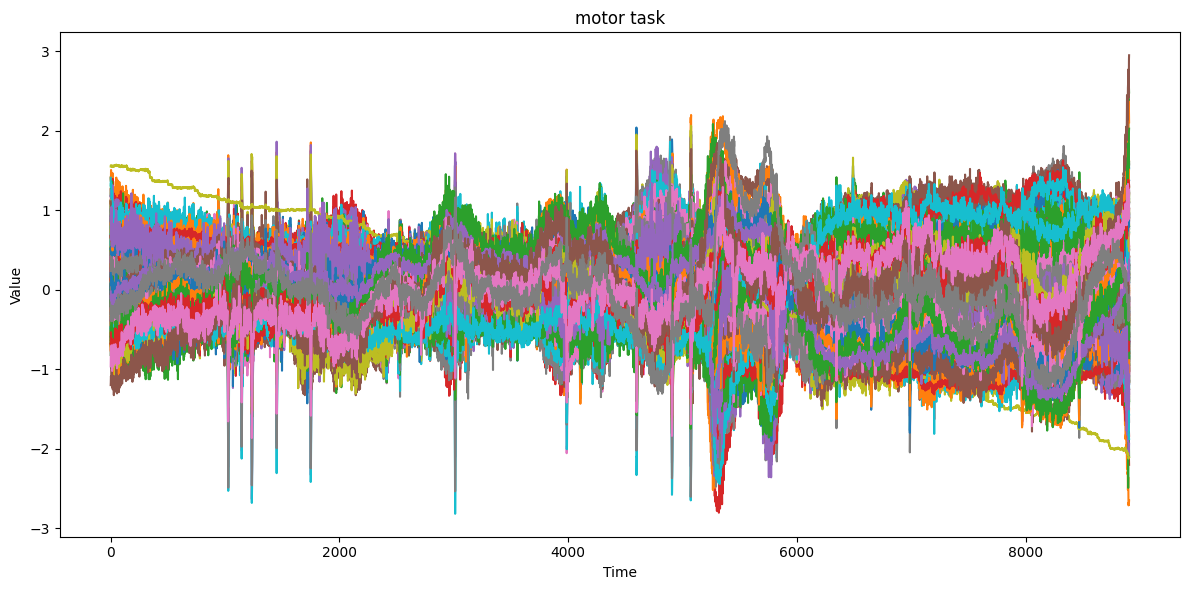

In [13]:
plt.figure(figsize=(12, 6))
for i in range(248):  # You can increase this to show more rows
    plt.plot(motor_data[i], label=f"Row {i}")

plt.xlabel("Time")
plt.ylabel("Value")
plt.title("motor task")
plt.tight_layout()
plt.show()

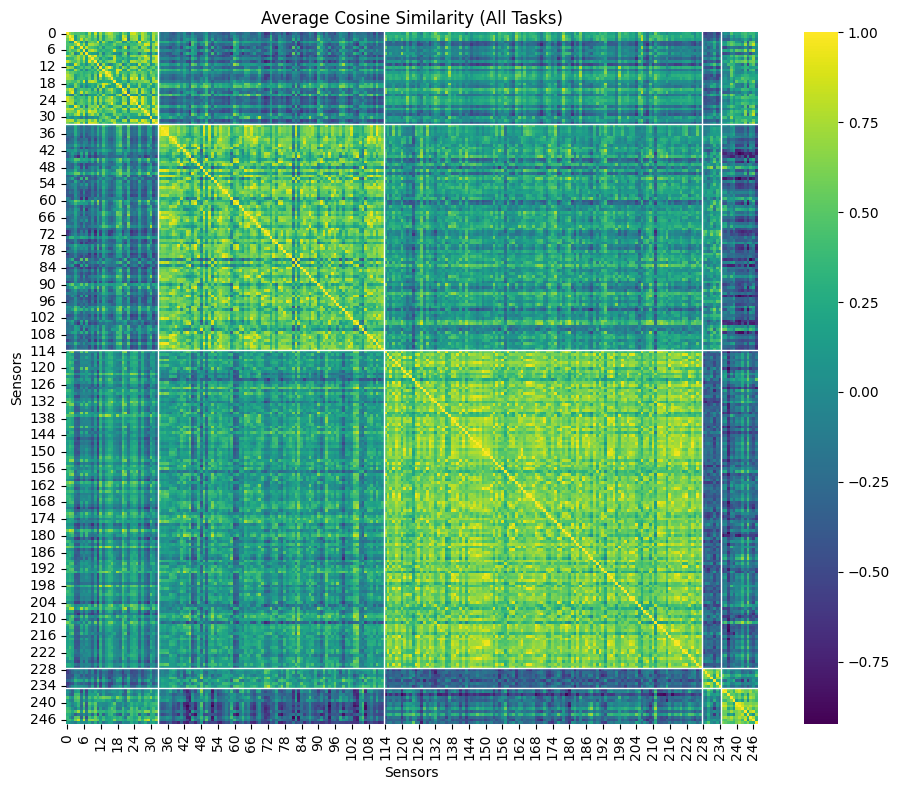

In [14]:
plot_avg_sensor_similarity(
    sim_matrix=avg_sim_matrix,
    sensor_order=sensor_order,
    cluster_labels=cluster_labels,
    title="Average Cosine Similarity (All Tasks)"
)

### Simple FFN

In [15]:
def extract_snapshots(data, time_per_snapshot=32, agg_func=np.mean, method='time'):
    """
    Extract 1s snapshots with time or space aggregation.
    """
    sensors, total_time = data.shape
    snapshots = []
    for start in range(0, total_time - time_per_snapshot + 1, time_per_snapshot):
        snap = data[:, start:start + time_per_snapshot]
        if method == 'time':
            agg = agg_func(snap, axis=1)
        else:
            agg = agg_func(snap, axis=0)
        snapshots.append(agg)
    return np.stack(snapshots)


### Aggregate the time dimension

In [16]:

label_map = {
    "rest": 0,
    "motor": 1,
    "story_math": 2,
    "wm": 3
}

# Prepare snapshot-level dataset
X_rest = extract_snapshots(rest_data, method='time')
X_motor = extract_snapshots(motor_data, method='time')
X_story = extract_snapshots(story_math_data, method='time')
X_wm = extract_snapshots(wm_data, method='time')

y_rest = np.full((X_rest.shape[0],), label_map['rest'])
y_motor = np.full((X_motor.shape[0],), label_map['motor'])
y_story = np.full((X_story.shape[0],), label_map['story_math'])
y_wm = np.full((X_wm.shape[0],), label_map['wm'])

X_all = np.concatenate([X_rest, X_motor, X_story, X_wm])
y_all = np.concatenate([y_rest, y_motor, y_story, y_wm])


# shuffle??
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all, test_size=0.2, stratify=y_all, random_state=42)

In [17]:
# Prepare data
# Build FFNN model
def build_ffnn(input_shape, dense_units=128, dropout_rate=0.3, num_classes=4):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Dense(dense_units, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(dense_units // 2, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

# Instantiate and compile
snapshot_model = build_ffnn(input_shape=(X_train.shape[1],))

snapshot_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train
snapshot_history = snapshot_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=16,
    verbose=1
)

Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5113 - loss: 1.2024 - val_accuracy: 0.8969 - val_loss: 0.4765
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8621 - loss: 0.5047 - val_accuracy: 0.9910 - val_loss: 0.1773
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9608 - loss: 0.2461 - val_accuracy: 0.9955 - val_loss: 0.0714
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9742 - loss: 0.1530 - val_accuracy: 1.0000 - val_loss: 0.0350
Epoch 5/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9822 - loss: 0.0916 - val_accuracy: 1.0000 - val_loss: 0.0194
Epoch 6/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9786 - loss: 0.0817 - val_accuracy: 1.0000 - val_loss: 0.0162
Epoch 7/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9865 - loss: 0.0441 - val_accuracy: 1.0000 - val_loss: 0.0088
Epoch 8/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9884 - loss: 0.0464 - val_accuracy: 1.0000 - val_loss:

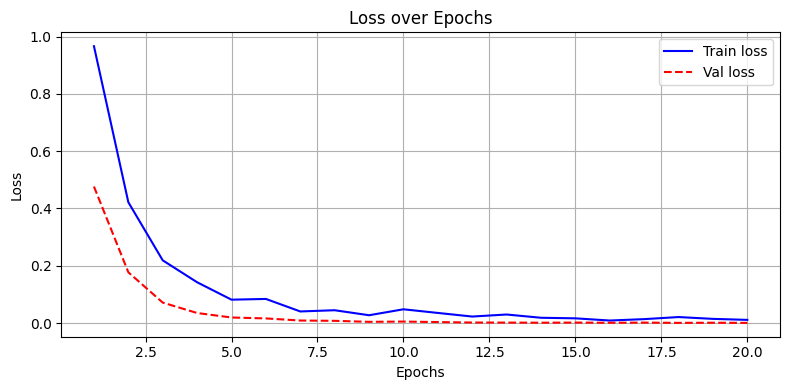

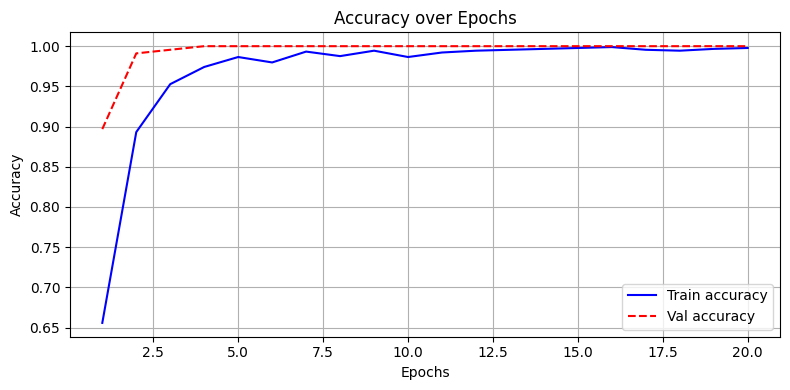

In [18]:
plot_training_history(snapshot_history, metrics=['loss', 'accuracy'])

In [19]:
from scipy.stats import mode

def predict_full_sequence(model, data, method='time', time_per_snapshot=32, agg='mean'):
    snapshots = extract_snapshots(data, time_per_snapshot, method=method)
    snapshots = np.asarray(snapshots)  # Ensure it's a proper ndarray
    probs = model.predict(snapshots)   # Shape: (num_snapshots, num_classes)

    if agg == 'mean':
        return int(np.argmax(np.mean(probs, axis=0)))
    elif agg == 'vote':
        preds = np.argmax(probs, axis=1)
        return int(mode(preds).mode[0])
    else:
        raise ValueError("Unsupported aggregation method.")



In [20]:
X_sequences = [rest_data, motor_data, story_math_data, wm_data]
y_true = [0, 1, 2, 3]  # true labels corresponding to above

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


y_pred = [predict_full_sequence(snapshot_model, seq, method = 'time') for seq in X_sequences]
print("Accuracy:", accuracy_score(y_true, y_pred))
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=label_map.keys()))
print("\nConfusion Matrix:\n", confusion_matrix(y_true, y_pred))
print("Snapshot validation accuracy:", snapshot_model.evaluate(X_val, y_val)[1])
print("Sequence aggregated accuracy:", accuracy_score(y_true, y_pred))

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

        rest       1.00      1.00      1.00         1
       motor       1.00      1.00      1.00         1
  story_math       1.00      1.00      1.00         1
          wm       1.00      1.00      1.00         1

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4


Confusion Matrix:
 [[1 0 0 0]
 [0 1 0 0]
 [0 0 1 0]
 [0 0 0 1]]
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 7.5049e-04
Snapshot validation accuracy: 1.0
Sequence aggregated accuracy: 1.0


### Aggregate the space dimension

In [21]:

label_map = {
    "rest": 0,
    "motor": 1,
    "story_math": 2,
    "wm": 3
}

# Prepare snapshot-level dataset
X_rest = extract_snapshots(rest_data, method='space')
X_motor = extract_snapshots(motor_data, method='space')
X_story = extract_snapshots(story_math_data, method='space')
X_wm = extract_snapshots(wm_data, method='space')

y_rest = np.full((X_rest.shape[0],), label_map['rest'])
y_motor = np.full((X_motor.shape[0],), label_map['motor'])
y_story = np.full((X_story.shape[0],), label_map['story_math'])
y_wm = np.full((X_wm.shape[0],), label_map['wm'])

X_all = np.concatenate([X_rest, X_motor, X_story, X_wm])
y_all = np.concatenate([y_rest, y_motor, y_story, y_wm])


# shuffle??
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all, test_size=0.2, stratify=y_all, random_state=42)

In [22]:
snapshot_model_space = build_ffnn(input_shape=(X_train.shape[1],))

snapshot_model_space.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train
snapshot_space_history = snapshot_model_space.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=16,
    verbose=1
)

Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.2273 - loss: 1.3900 - val_accuracy: 0.2646 - val_loss: 1.3797
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2679 - loss: 1.3668 - val_accuracy: 0.3274 - val_loss: 1.3724
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2991 - loss: 1.3739 - val_accuracy: 0.2825 - val_loss: 1.3685
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3198 - loss: 1.3628 - val_accuracy: 0.3498 - val_loss: 1.3501
Epoch 5/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3399 - loss: 1.3476 - val_accuracy: 0.3632 - val_loss: 1.3351
Epoch 6/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3426 - loss: 1.3399 - val_accuracy: 0.3229 - val_loss: 1.3309
Epoch 7/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3936 - loss: 1.3190 - val_accuracy: 0.3722 - val_loss: 1.3249
Epoch 8/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4077 - loss: 1.3178 - val_accuracy: 0.3901 - val_loss:

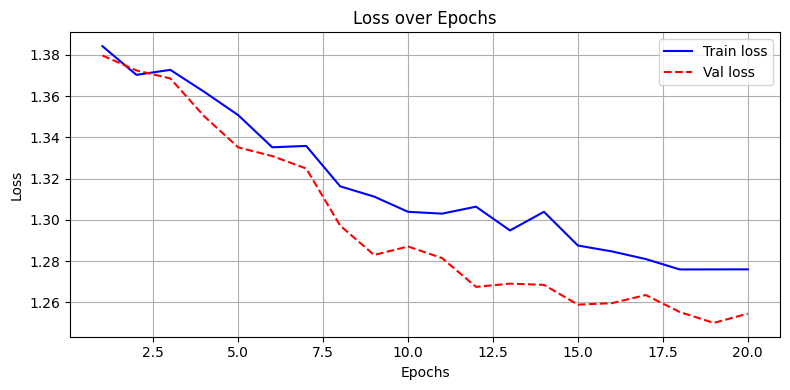

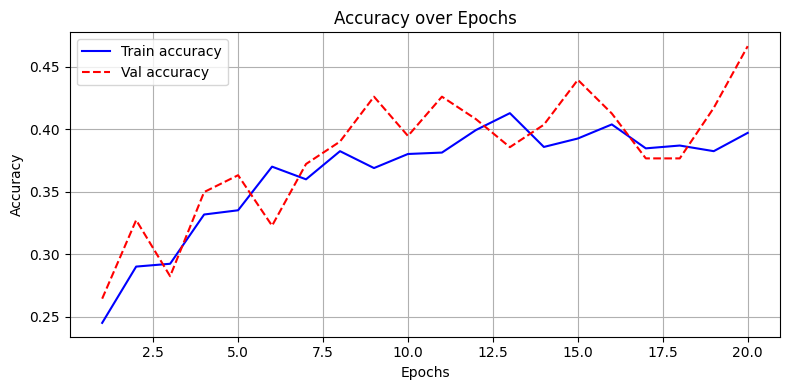

In [23]:
plot_training_history(snapshot_space_history, metrics=['loss', 'accuracy'])

In [24]:
from scipy.stats import mode

def predict_full_sequence(model, data, method = 'space', time_per_snapshot=32, agg='mean'):
    snapshots = extract_snapshots(data, method = method, time_per_snapshot = time_per_snapshot)
    probs = model.predict(snapshots)

    if agg == 'mean':
        return int(np.argmax(np.mean(probs, axis=0)))
    elif agg == 'vote':
        preds = np.argmax(probs, axis=1)
        return int(mode(preds).mode[0])


In [25]:
X_sequences = [rest_data, motor_data, story_math_data, wm_data]
y_true = [0, 1, 2, 3]  # true labels corresponding to above

y_pred = [predict_full_sequence(snapshot_model_space, seq, method = 'space') for seq in X_sequences]
print("Accuracy:", accuracy_score(y_true, y_pred))
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=label_map.keys()))
print("\nConfusion Matrix:\n", confusion_matrix(y_true, y_pred))
print("Snapshot validation accuracy:", snapshot_model_space.evaluate(X_val, y_val)[1])
print("Sequence aggregated accuracy:", accuracy_score(y_true, y_pred))


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

        rest       1.00      1.00      1.00         1
       motor       1.00      1.00      1.00         1
  story_math       1.00      1.00      1.00         1
          wm       1.00      1.00      1.00         1

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4


Confusion Matrix:
 [[1 0 0 0]
 [0 1 0 0]
 [0 0 1 0]
 [0 0 0 1]]
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4659 - loss: 1.2540 
Snapshot validation accuracy: 0.4663677215576172
Sequence aggregated accuracy: 1.0


# Testing

In [26]:
# intra 1
participant_id_intra = 105923
rest_intra, motor_intra, story_math_intra, wm_intra = load_participant_arrays(participant_id_intra, base_dir=r"/content/drive/MyDrive/DL part 2/Final Project data/Intra/test")


print("Rest:", None if rest_intra is None else rest_intra.shape)
print("Motor:", None if motor_intra is None else motor_intra.shape)
print("Story/Math:", None if story_math_intra is None else story_math_intra.shape)
print("Working Memory:", None if wm_intra is None else wm_intra.shape)


Rest: (248, 71248)
Motor: (248, 71248)
Story/Math: (248, 71248)
Working Memory: (248, 71248)


In [27]:
datasets = [rest_intra, motor_intra, story_math_intra, wm_intra]
task_names = ["rest", "motor", "story_math", "wm"]

# preprocessing all datasets
preprocessed_datasets = [
    preprocess_meg_data(
        data,
        scaling="zscore",
        downsample_method="decimate",
        target_rate=64,
        orig_rate=2034
    )
    for data in datasets
]

# clustering using averaged cosine similarity
sensor_order, cluster_labels, avg_sim_matrix = cossim_cluster_multi_task(
    preprocessed_datasets,
    n_clusters=5
)

# reorder and store data per task
reordered_data_dict = {}
sensor_order_dict = {}
cluster_labels_dict = {}

for preproc_data, name in zip(preprocessed_datasets, task_names):
    reordered_data = preproc_data[sensor_order, :]
    reordered_data_dict[f"reordered_data_{name}"] = reordered_data
    sensor_order_dict[f"sensor_order_{name}"] = sensor_order
    cluster_labels_dict[f"cluster_labels_{name}"] = cluster_labels


In [28]:
rest_data = reordered_data_dict["reordered_data_rest"]
rest_sensor_order = sensor_order_dict["sensor_order_rest"]
rest_clusters = cluster_labels_dict["cluster_labels_rest"]

motor_data = reordered_data_dict["reordered_data_motor"]
motor_sensor_order = sensor_order_dict["sensor_order_motor"]
motor_clusters = cluster_labels_dict["cluster_labels_motor"]

story_math_data = reordered_data_dict["reordered_data_story_math"]
story_math_sensor_order = sensor_order_dict["sensor_order_story_math"]
story_math_clusters = cluster_labels_dict["cluster_labels_story_math"]

wm_data = reordered_data_dict["reordered_data_wm"]
wm_sensor_order = sensor_order_dict["sensor_order_wm"]
wm_clusters = cluster_labels_dict["cluster_labels_wm"]

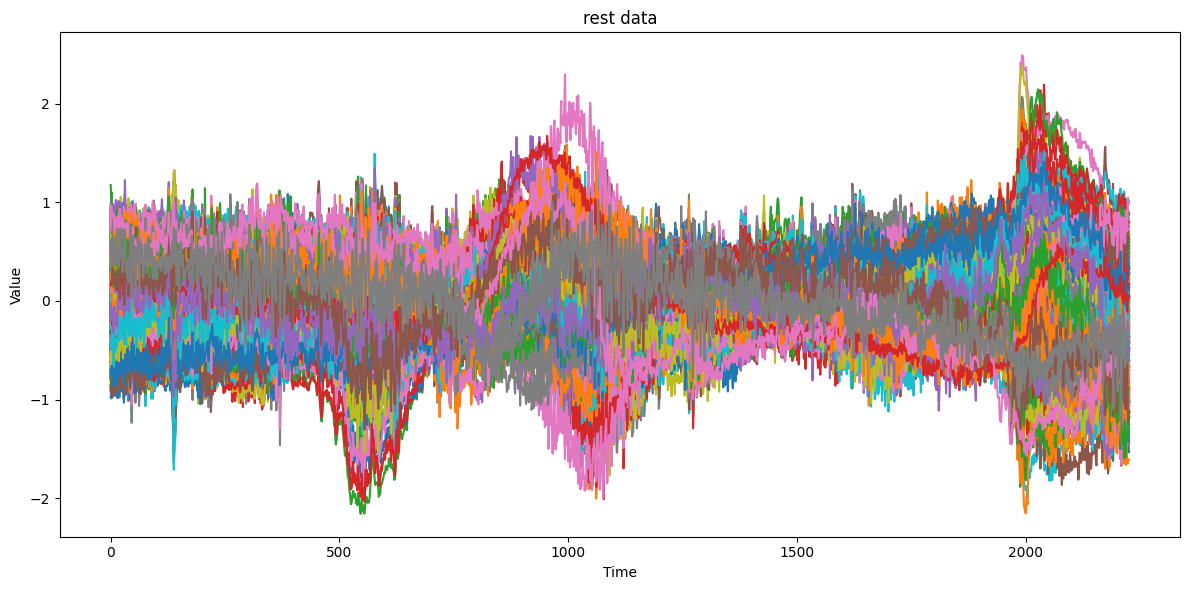

In [29]:
plt.figure(figsize=(12, 6))
for i in range(248):  # You can increase this to show more rows
    plt.plot(rest_data[i], label=f"Row {i}")

plt.xlabel("Time")
plt.ylabel("Value")
plt.title("rest data")
plt.tight_layout()
plt.show()

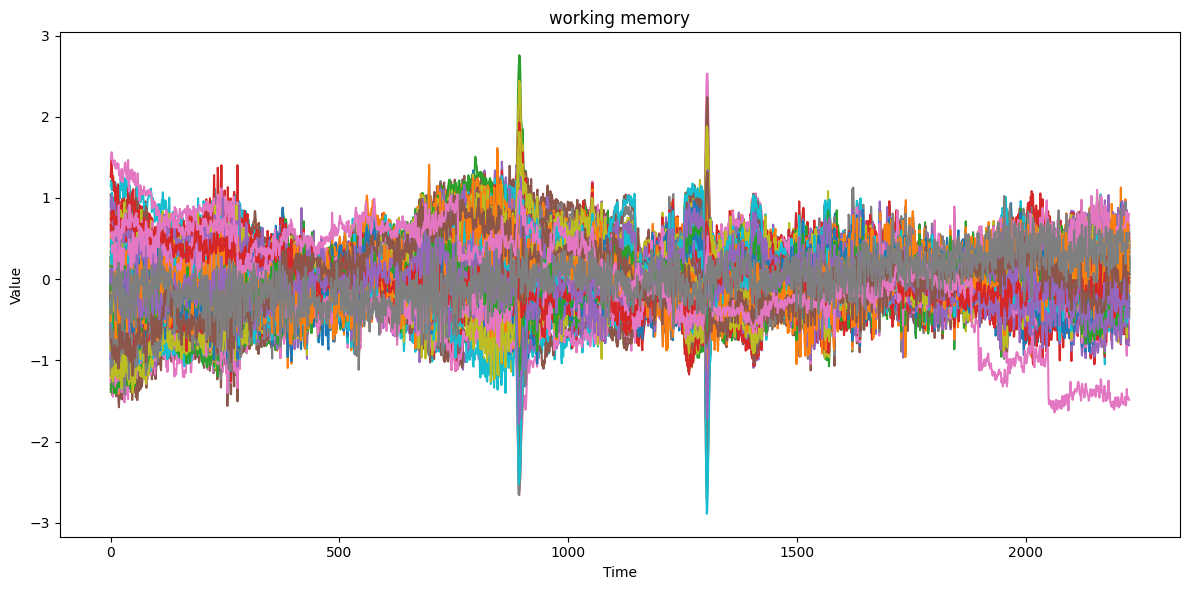

In [30]:
plt.figure(figsize=(12, 6))
for i in range(248):  # You can increase this to show more rows
    plt.plot(wm_data[i], label=f"Row {i}")

plt.xlabel("Time")
plt.ylabel("Value")
plt.title("working memory")
plt.tight_layout()
plt.show()

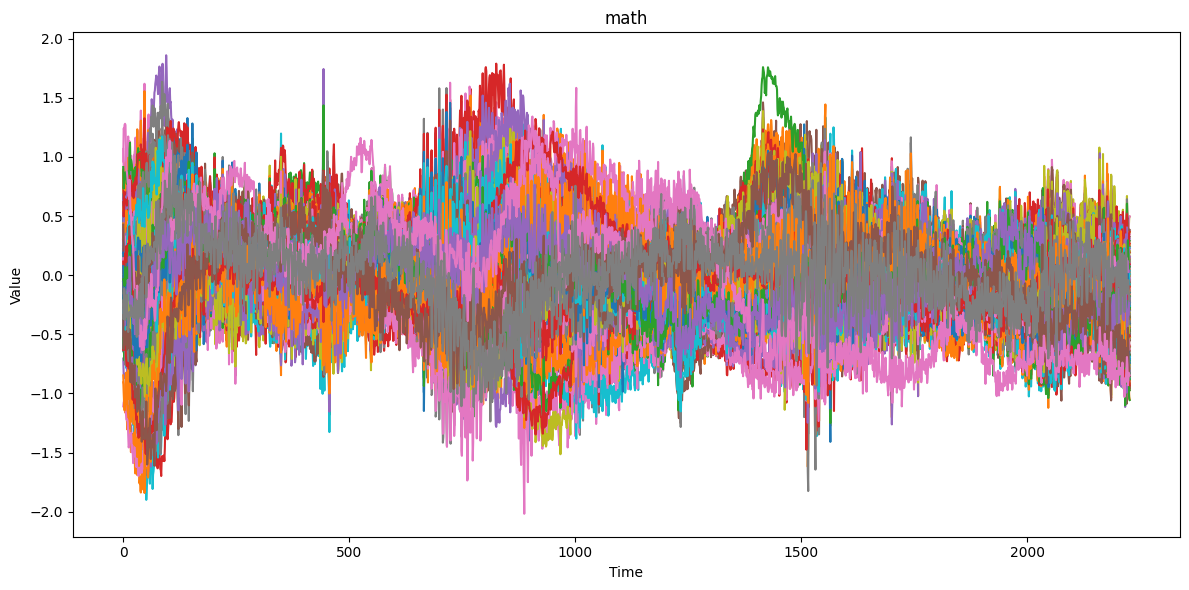

In [31]:
plt.figure(figsize=(12, 6))
for i in range(248):  # You can increase this to show more rows
    plt.plot(story_math_data[i], label=f"Row {i}")

plt.xlabel("Time")
plt.ylabel("Value")
plt.title("math")
plt.tight_layout()
plt.show()

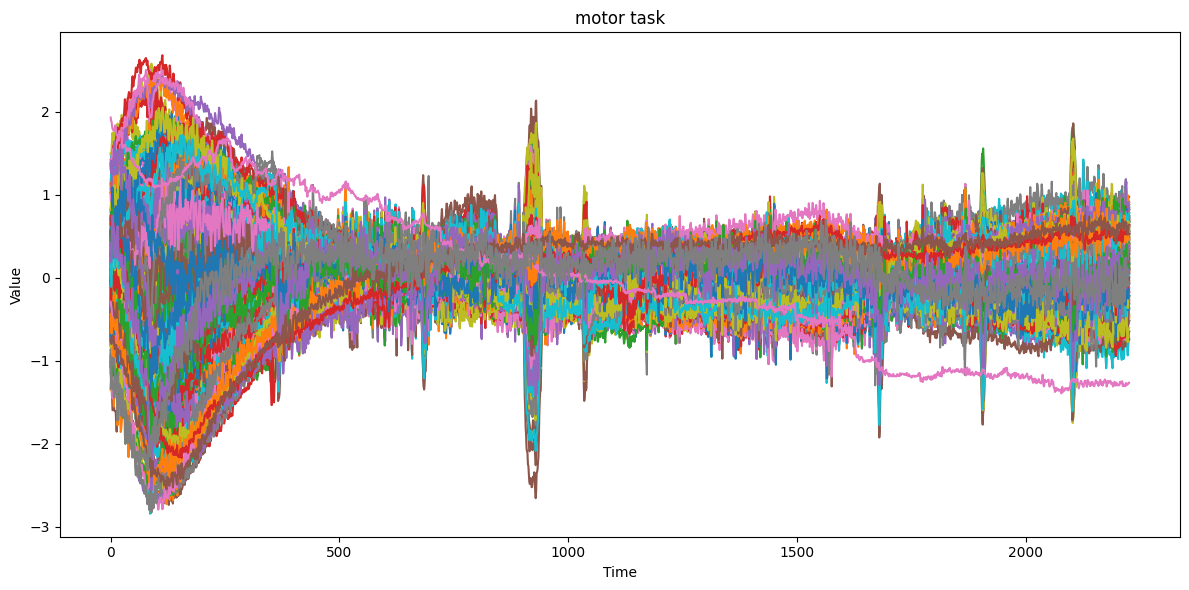

In [32]:
plt.figure(figsize=(12, 6))
for i in range(248):  # You can increase this to show more rows
    plt.plot(motor_data[i], label=f"Row {i}")

plt.xlabel("Time")
plt.ylabel("Value")
plt.title("motor task")
plt.tight_layout()
plt.show()

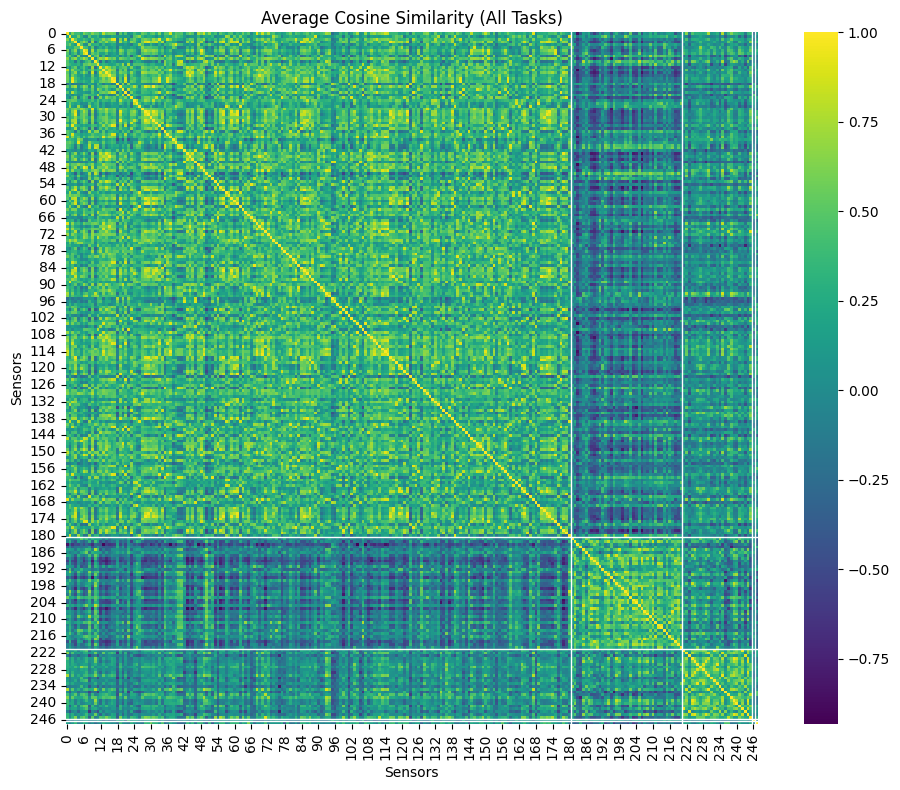

In [33]:
plot_avg_sensor_similarity(
    sim_matrix=avg_sim_matrix,
    sensor_order=sensor_order,
    cluster_labels=cluster_labels,
    title="Average Cosine Similarity (All Tasks)"
)

# Time aggregated

In [35]:
# Predicting on the test data
X_test_sequences = [rest_data, motor_data, story_math_data, wm_data]
y_test_true = [0, 1, 2, 3]  # True labels in order

y_test_pred = [predict_full_sequence(snapshot_model, seq, method='time') for seq in X_test_sequences]

# Print Results
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Test Accuracy:", accuracy_score(y_test_true, y_test_pred))
print("\nClassification Report:\n", classification_report(y_test_true, y_test_pred, target_names=label_map.keys()))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_true, y_test_pred))
#print("Snapshot validation accuracy:", snapshot_model.evaluate(X_val, y_val)[1])
#print("Sequence aggregated accuracy:", accuracy_score(y_test_true, y_test_pred))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Test Accuracy: 0.25

Classification Report:
               precision    recall  f1-score   support

        rest       0.00      0.00      0.00         1
       motor       0.00      0.00      0.00         1
  story_math       0.25      1.00      0.40         1
          wm       0.00      0.00      0.00         1

    accuracy                           0.25         4
   macro avg       0.06      0.25      0.10         4
weighted avg       0.06      0.25      0.10         4


Confusion Matrix:
 [[0 0 1 0]
 [0 0 1 0]
 [0 0 1 0]
 [0 0 1 0]]


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [42]:
from sklearn.metrics import accuracy_score

print("=== Snapshot Accuracy (Time Aggregation) ===")
for task_name, data in {
    "rest": rest_data,
    "motor": motor_data,
    "story_math": story_math_data,
    "wm": wm_data
}.items():
    snapshots = extract_snapshots(data, method='time')
    predictions = snapshot_model.predict(snapshots)
    labels = np.argmax(predictions, axis=1)
    true_labels = [label_map[task_name]] * len(labels)
    print(true_labels)
    print(labels)
    acc = accuracy_score(true_labels, labels)
    print(f"{task_name.capitalize():<12}: {acc:.4f}")



=== Snapshot Accuracy (Time Aggregation) ===
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[2 2 2 2 2 2 2 2 3 3 3 2 2 2 2 2 2 2 2 2 2 2 3 2 2 2 2 2 2 2 0 3 3 3 0 0 0
 0 0 0 0 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 0 0 0 0 3]
Rest        : 0.2029
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
[0 0 3 3 3 3 3 3 3 3 3 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 2 2 0 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]
Motor       : 0.0000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2

# Space aggregation

In [36]:
y_test_pred_space = [predict_full_sequence(snapshot_model_space, seq, method='space') for seq in X_test_sequences]

print("Test Accuracy (space):", accuracy_score(y_test_true, y_test_pred_space))
print("\nClassification Report:\n", classification_report(y_test_true, y_test_pred_space, target_names=label_map.keys()))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_true, y_test_pred_space))


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Test Accuracy (space): 0.25

Classification Report:
               precision    recall  f1-score   support

        rest       0.00      0.00      0.00         1
       motor       0.25      1.00      0.40         1
  story_math       0.00      0.00      0.00         1
          wm       0.00      0.00      0.00         1

    accuracy                           0.25         4
   macro avg       0.06      0.25      0.10         4
weighted avg       0.06      0.25      0.10         4


Confusion Matrix:
 [[0 1 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 1 0 0]]


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [39]:
print("\n=== Snapshot Accuracy (Space Aggregation) ===")
for task_name, data in {
    "rest": rest_data,
    "motor": motor_data,
    "story_math": story_math_data,
    "wm": wm_data
}.items():
    snapshots = extract_snapshots(data, method='space')
    predictions = snapshot_model_space.predict(snapshots)
    labels = np.argmax(predictions, axis=1)
    true_labels = [label_map[task_name]] * len(labels)
    acc = accuracy_score(true_labels, labels)
    print(f"{task_name.capitalize():<12}: {acc:.4f}")



=== Snapshot Accuracy (Space Aggregation) ===
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Rest        : 0.1304
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Motor       : 0.6522
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Story_math  : 0.3478
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Wm          : 0.2464
